# Модели

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)


## План

Сначала сравниваю четыре разных семейства моделей на одной `StratifiedKFold` из пяти фолдов, затем получаю OOF-предсказания и собираю rank blend.

Вся обучаемая предобработка находится внутри пайплайнов. `PCA(n_components=2)` помог только GaussianNB в feature engineering; для остальных моделей он ухудшил CV, поэтому дальше PCA не использую.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


SEED = 143

N_TRIALS_LOGREG = 6
N_TRIALS_RF = 4
N_TRIALS_LGBM = 8

OUTPUTS_DIR = Path("outputs")
LOCAL_DIR = Path(".local")

OUTPUTS_DIR.mkdir(exist_ok=True)
LOCAL_DIR.mkdir(exist_ok=True)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.CRITICAL)


/Users/pinta/Dev/mlStart/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


## Данные и валидация

Удаляю только почти константные признаки, выбранные в feature engineering. Один и тот же `cv` используется для подбора параметров, OOF-предсказаний и сравнения моделей.


In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

X_train = train_df.drop(columns=['id', 'target', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_car_10_cat'])  # см. feature engineering
y_train = train_df['target']

X_test = test_df.drop(columns=['id', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_car_10_cat'])  # см. feature engineering

cat_columns = [column for column in X_train.columns if column.endswith('_cat')]
num_columns = [column for column in X_train.columns if column not in cat_columns]


In [4]:
def normalized_gini(y_true, y_pred_proba):  # в cross_val_score по умолчанию его нет, но он легко выражается из roc_auc
    return 2 * roc_auc_score(y_true, y_pred_proba) - 1


gini_scorer = make_scorer(
    normalized_gini,
    response_method="predict_proba",
)


submission_names = {
    "gaussian_nb": "gnb_submission.csv",
    "logistic_regression": "logreg_submission.csv",
    "random_forest": "rf_submission.csv",
    "lightgbm": "lgbm_submission.csv",
}


def get_model_dir(model_name):
    model_dir = LOCAL_DIR / model_name
    model_dir.mkdir(exist_ok=True)

    return model_dir


def evaluate_trial(model, X, y, score_history, n_jobs=-1):
    scores = cross_val_score(model, X, y, cv=cv, scoring=gini_scorer, n_jobs=n_jobs)

    score_history.append({
        'val_gini': scores[0],
        'other_folds_gini': scores[1:].mean(),
        'mean_gini': scores.mean(),
    })

    return scores.mean()


def run_optuna(objective, model_name, n_trials):
    study = optuna.create_study(
        study_name=model_name,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=2),
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        gc_after_trial=False,
        show_progress_bar=False
    )

    model_dir = get_model_dir(model_name)
    study.trials_dataframe().to_csv(model_dir / "optuna_trials.csv", index=False)

    with open(model_dir / "best_params.json", "w") as file:
        json.dump(study.best_params, file, indent=4)

    return study


def plot_score_history(score_history, model_name, title):
    model_dir = get_model_dir(model_name)

    history = pd.DataFrame(score_history)
    history.index = np.arange(1, len(history) + 1)
    history.index.name = "iteration"

    history["gap"] = history["val_gini"] - history["other_folds_gini"]
    history.to_csv(model_dir / "score_history.csv")

    learning_curve = history[
        ["val_gini", "other_folds_gini"]
    ].rename(columns={
        "val_gini": "val fold",
        "other_folds_gini": "mean other folds",
    })

    ax = learning_curve.plot(
        figsize=(10, 5),
        marker="o",
        xlabel="Iteration",
        ylabel="Normalized Gini",
        title=title
    )

    figure = ax.get_figure()
    figure.savefig(model_dir / "learning_curve.png", bbox_inches="tight")
    plt.show()

    return history


def get_oof_predictions(model, X, y, n_jobs=1):
    predictions = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=n_jobs
    )[:, 1]

    fold_scores = []

    for _, valid_index in cv.split(X, y):
        fold_scores.append(normalized_gini(y.iloc[valid_index], predictions[valid_index]))

    return predictions, np.array(fold_scores)


def save_model_outputs(model_name, oof_predictions, test_predictions):
    model_dir = get_model_dir(model_name)

    pd.DataFrame({
        "id": train_df["id"],
        "target": y_train,
        "prediction": oof_predictions,
    }).to_csv(model_dir / "oof_predictions.csv", index=False)

    submission = pd.DataFrame({
        "id": test_df["id"],
        "target": test_predictions,
    })

    submission.to_csv(
        OUTPUTS_DIR / submission_names[model_name],
        index=False
    )

    return submission


### GaussianNB

Быстрый baseline. Категориальные признаки кодируются через `OneHotEncoder` внутри CV-пайплайна.


In [5]:
gaussian_nb_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
            make_column_selector(pattern='_cat$')
        )
    ],
    remainder='passthrough'
)

gaussian_nb_model = make_pipeline(
    gaussian_nb_preprocessor,
    GaussianNB()
)

gaussian_nb_oof, gaussian_nb_fold_scores = get_oof_predictions(
    gaussian_nb_model,
    X_train,
    y_train,
    n_jobs=-1
)

pd.DataFrame({
    'model': ['gaussian_nb'],
    'mean_gini': [gaussian_nb_fold_scores.mean()],
    'std_gini': [gaussian_nb_fold_scores.std()],
})


,model,mean_gini,std_gini
0,gaussian_nb,0.180968,0.009682


In [6]:
gaussian_nb_model.fit(X_train, y_train)

gaussian_nb_test_predictions = gaussian_nb_model.predict_proba(X_test)[:, 1]

gaussian_nb_submission = save_model_outputs(
    "gaussian_nb",
    gaussian_nb_oof,
    gaussian_nb_test_predictions
)

gaussian_nb_submission.head()


,id,target
0,0,9.697845e-10
1,1,6.981414e-09
2,2,2.188061e-07
3,3,3.835647e-10
4,4,2.158711e-06


### Logistic Regression

Линейный baseline с One-Hot Encoding и масштабированием внутри пайплайна. Optuna подбирает силу и тип регуляризации через `C` и `l1_ratio`.


In [7]:
logistic_regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            make_column_selector(pattern='_cat$')
        )
    ],
    remainder=StandardScaler(),
    sparse_threshold=1.0
)


In [8]:
logistic_regression_score_history = []

def logistic_regression_objective(trial):
    params = {
        "C": trial.suggest_categorical("C", [0.01, 0.03, 0.1]),
        "l1_ratio": trial.suggest_categorical("l1_ratio", [0.0, 0.25, 0.5]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }

    model = make_pipeline(
        logistic_regression_preprocessor,
        LogisticRegression(
            **params,
            solver="saga",
            random_state=SEED,
            max_iter=2_000,
            tol=1e-3
        )
    )

    return evaluate_trial(
        model,
        X_train,
        y_train,
        logistic_regression_score_history,
        n_jobs=-1
    )


In [9]:
logistic_regression_study = run_optuna(
    logistic_regression_objective,
    "logistic_regression",
    N_TRIALS_LOGREG
)

best_params_logistic_regression = logistic_regression_study.best_params
best_score_logistic_regression = logistic_regression_study.best_value


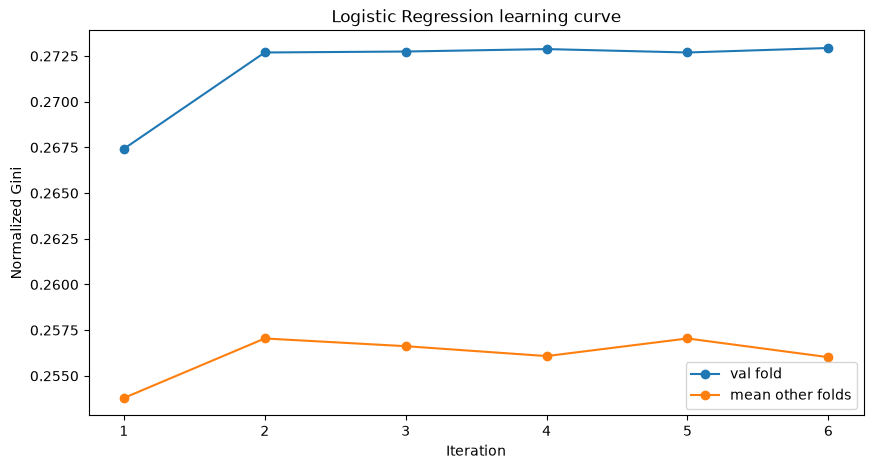

In [10]:
logistic_regression_history = plot_score_history(
    logistic_regression_score_history,
    "logistic_regression",
    "Logistic Regression learning curve"
)


In [11]:
logistic_regression_model = make_pipeline(
    logistic_regression_preprocessor,
    LogisticRegression(
        **best_params_logistic_regression,
        solver="saga",
        random_state=SEED,
        max_iter=2_000,
        tol=1e-3
    )
)

logistic_regression_oof, logistic_regression_fold_scores = get_oof_predictions(
    logistic_regression_model,
    X_train,
    y_train,
    n_jobs=-1
)

logistic_regression_model.fit(X_train, y_train)
logistic_regression_test_predictions = logistic_regression_model.predict_proba(X_test)[:, 1]

logistic_regression_submission = save_model_outputs(
    "logistic_regression",
    logistic_regression_oof,
    logistic_regression_test_predictions
)

logistic_regression_submission.head()


,id,target
0,0,0.030522
1,1,0.031762
2,2,0.027029
3,3,0.018036
4,4,0.036387


### Random Forest

Нелинейная bagging-модель. Пространство параметров ограничено, чтобы лес не занимал несоразмерно больше времени, чем остальные модели.


In [12]:
random_forest_score_history = []

def random_forest_objective(trial):
    params = {
        "n_estimators": trial.suggest_categorical("n_estimators", [80, 120, 160]),
        "max_depth": trial.suggest_categorical("max_depth", [6, 8, 10]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [50, 100, 200]),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", 0.25]),
        "max_samples": trial.suggest_categorical("max_samples", [0.25, 0.4]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced_subsample"]),
    }

    model = RandomForestClassifier(
        **params,
        random_state=SEED,
        n_jobs=-1,
    )

    return evaluate_trial(
        model,
        X_train,
        y_train,
        random_forest_score_history,
        n_jobs=1
    )


In [13]:
random_forest_study = run_optuna(
    random_forest_objective,
    "random_forest",
    N_TRIALS_RF
)

best_params_random_forest = random_forest_study.best_params
best_score_random_forest = random_forest_study.best_value


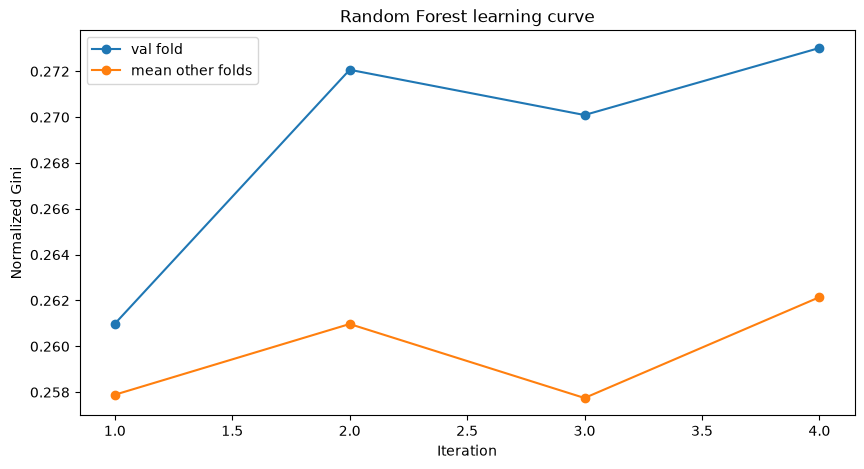

In [14]:
random_forest_history = plot_score_history(
    random_forest_score_history,
    "random_forest",
    "Random Forest learning curve"
)


In [15]:
random_forest_model = RandomForestClassifier(
    **best_params_random_forest,
    random_state=SEED,
    n_jobs=-1,
)

random_forest_oof, random_forest_fold_scores = get_oof_predictions(
    random_forest_model,
    X_train,
    y_train,
    n_jobs=1
)

random_forest_model.fit(X_train, y_train)
random_forest_test_predictions = random_forest_model.predict_proba(X_test)[:, 1]

random_forest_submission = save_model_outputs(
    "random_forest",
    random_forest_oof,
    random_forest_test_predictions
)

random_forest_submission.head()


,id,target
0,0,0.026132
1,1,0.027219
2,2,0.032807
3,3,0.017395
4,4,0.034087


### LightGBM

Основная бустинговая модель. `_cat`-признаки переводятся в `pandas.Categorical` только в отдельных копиях данных для LightGBM.


In [16]:
X_train_lightgbm = X_train.copy()
X_test_lightgbm = X_test.copy()

for column in cat_columns:
    categories = pd.Index(X_train[column].unique())
    X_train_lightgbm[column] = pd.Categorical(X_train[column], categories=categories)
    X_test_lightgbm[column] = pd.Categorical(X_test[column], categories=categories)


In [17]:
lightgbm_score_history = []

def lightgbm_objective(trial):
    params = {
        "num_leaves": trial.suggest_categorical("num_leaves", [15, 31, 63]),
        "learning_rate": trial.suggest_categorical("learning_rate", [0.02, 0.03, 0.05]),
        "n_estimators": trial.suggest_categorical("n_estimators", [300, 450, 600]),
        "min_child_samples": trial.suggest_categorical("min_child_samples", [50, 100, 200]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.7, 0.85, 1.0]),
        "subsample": trial.suggest_categorical("subsample", [0.7, 0.85, 1.0]),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.1, 1.0, 5.0]),
    }

    model = LGBMClassifier(
        **params,
        subsample_freq=1,
        verbosity=-1,
        random_state=SEED,
        n_jobs=-1,
    )

    return evaluate_trial(
        model,
        X_train_lightgbm,
        y_train,
        lightgbm_score_history,
        n_jobs=1
    )


In [18]:
lightgbm_study = run_optuna(
    lightgbm_objective,
    "lightgbm",
    N_TRIALS_LGBM
)

best_params_lightgbm = lightgbm_study.best_params
best_score_lightgbm = lightgbm_study.best_value


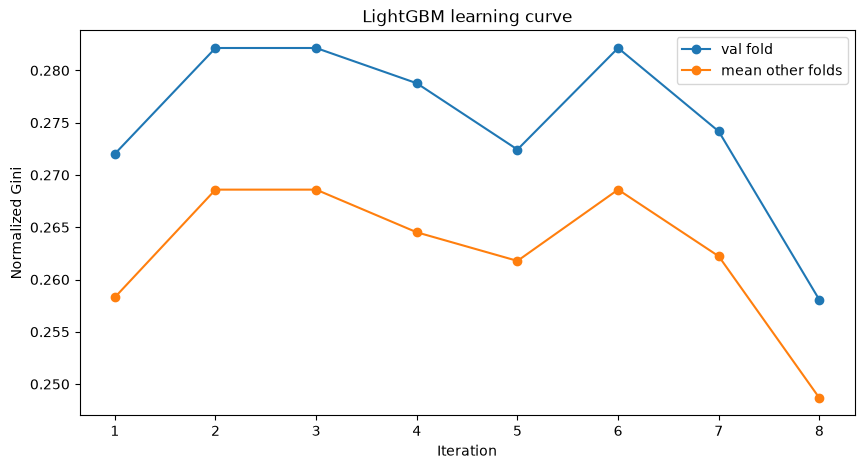

In [19]:
lightgbm_history = plot_score_history(
    lightgbm_score_history,
    "lightgbm",
    "LightGBM learning curve"
)


In [20]:
lightgbm_model = LGBMClassifier(
    **best_params_lightgbm,
    subsample_freq=1,
    verbosity=-1,
    random_state=SEED,
    n_jobs=-1,
)

lightgbm_oof, lightgbm_fold_scores = get_oof_predictions(
    lightgbm_model,
    X_train_lightgbm,
    y_train,
    n_jobs=1
)

lightgbm_model.fit(X_train_lightgbm, y_train)
lightgbm_test_predictions = lightgbm_model.predict_proba(X_test_lightgbm)[:, 1]

lightgbm_submission = save_model_outputs(
    "lightgbm",
    lightgbm_oof,
    lightgbm_test_predictions
)

lightgbm_submission.head()


,id,target
0,0,0.027742
1,1,0.026942
2,2,0.024212
3,3,0.017044
4,4,0.038998


## Сравнение и блендинг

Сравниваю модели по честным OOF-предсказаниям. Корреляцию считаю по рангам: для Gini важен порядок объектов, а не масштаб вероятностей.


In [21]:
model_scores = pd.DataFrame([
    {
        "model": "gaussian_nb",
        "oof_gini": normalized_gini(y_train, gaussian_nb_oof),
        "mean_fold_gini": gaussian_nb_fold_scores.mean(),
        "std_fold_gini": gaussian_nb_fold_scores.std(),
    },
    {
        "model": "logistic_regression",
        "oof_gini": normalized_gini(y_train, logistic_regression_oof),
        "mean_fold_gini": logistic_regression_fold_scores.mean(),
        "std_fold_gini": logistic_regression_fold_scores.std(),
    },
    {
        "model": "random_forest",
        "oof_gini": normalized_gini(y_train, random_forest_oof),
        "mean_fold_gini": random_forest_fold_scores.mean(),
        "std_fold_gini": random_forest_fold_scores.std(),
    },
    {
        "model": "lightgbm",
        "oof_gini": normalized_gini(y_train, lightgbm_oof),
        "mean_fold_gini": lightgbm_fold_scores.mean(),
        "std_fold_gini": lightgbm_fold_scores.std(),
    },
]).sort_values("oof_gini", ascending=False).reset_index(drop=True)

blending_dir = get_model_dir("blending")
model_scores.to_csv(blending_dir / "model_scores.csv", index=False)

model_scores


,model,oof_gini,mean_fold_gini,std_fold_gini
0,lightgbm,0.271254,0.271309,0.006657
1,random_forest,0.264105,0.264319,0.008215
2,logistic_regression,0.260112,0.260175,0.009720
3,gaussian_nb,0.180574,0.180968,0.009682


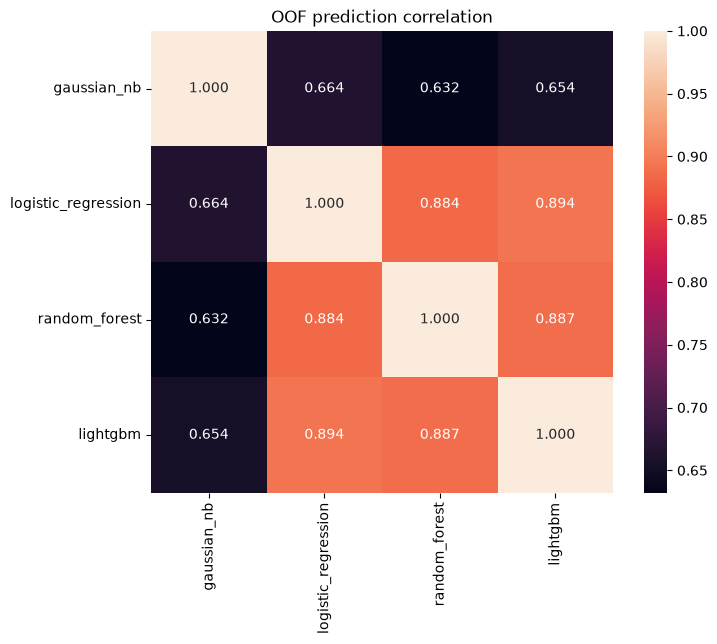

In [ ]:
oof_predictions = pd.DataFrame({
    "gaussian_nb": gaussian_nb_oof,
    "logistic_regression": logistic_regression_oof,
    "random_forest": random_forest_oof,
    "lightgbm": lightgbm_oof,
})

test_predictions = pd.DataFrame({
    "id": test_df["id"],
    "gaussian_nb": gaussian_nb_test_predictions,
    "logistic_regression": logistic_regression_test_predictions,
    "random_forest": random_forest_test_predictions,
    "lightgbm": lightgbm_test_predictions,
})

oof_predictions.assign(target=y_train.to_numpy()).to_csv(
    blending_dir / "oof_predictions.csv",
    index=False
)

test_predictions.to_csv(
    blending_dir / "test_predictions.csv",
    index=False
)

prediction_correlation = oof_predictions.corr(method="spearman")
prediction_correlation.to_csv(blending_dir / "prediction_correlation.csv")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    prediction_correlation,
    annot=True,
    fmt=".3f",
    square=True,
    ax=ax
)

ax.set_title("OOF prediction correlation")
fig.savefig(blending_dir / "prediction_correlation.png", bbox_inches="tight")

plt.show()


Проверю три варианта бленда лучших моделей:
1. одинаковые веса;
2. веса пропорционально OOF Gini;
3. веса, подобранные Optuna.

GaussianNB пока не добавляю: корреляция у него с остальными конечно сравнительная низкая, но и собственный скор заметно хуже, вряд ли его предикт нам поможет...


In [24]:
blend_models = [
    "logistic_regression",
    "random_forest",
    "lightgbm",
]


def rank_oof_predictions(predictions):
    ranked_predictions = predictions.copy()

    for _, valid_index in cv.split(X_train, y_train):
        ranked_predictions.iloc[valid_index] = (
            predictions.iloc[valid_index]
            .rank(pct=True)
            .to_numpy()
        )

    return ranked_predictions


def make_blend(predictions, weights):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    return predictions.to_numpy() @ weights


def get_blend_fold_scores(predictions):
    fold_scores = []

    for _, valid_index in cv.split(X_train, y_train):
        fold_scores.append(
            normalized_gini(
                y_train.iloc[valid_index],
                predictions[valid_index]
            )
        )

    return np.array(fold_scores)


def save_blend(blend_name, weights):
    oof_blend = make_blend(
        ranked_oof_predictions,
        weights
    )

    test_blend = make_blend(
        ranked_test_predictions,
        weights
    )

    fold_scores = get_blend_fold_scores(oof_blend)

    submission = pd.DataFrame({
        "id": test_df["id"],
        "target": test_blend,
    })

    submission.to_csv(
        OUTPUTS_DIR / f"{blend_name}_submission.csv",
        index=False
    )

    return {
        "blend": blend_name,
        "oof_gini": normalized_gini(y_train, oof_blend),
        "mean_fold_gini": fold_scores.mean(),
        "std_fold_gini": fold_scores.std(),
    }, oof_blend, test_blend


ranked_oof_predictions = rank_oof_predictions(
    oof_predictions[blend_models]
)

ranked_test_predictions = (
    test_predictions[blend_models]
    .rank(pct=True)
)

Равные веса:

In [25]:
equal_weights = np.ones(len(blend_models)) / len(blend_models)

model_gini = (
    model_scores
    .set_index("model")
    .loc[blend_models, "oof_gini"]
    .to_numpy()
)

score_weights = model_gini / model_gini.sum()

pd.DataFrame({
    "model": blend_models,
    "equal": equal_weights,
    "score_weighted": score_weights,
})

,model,equal,score_weighted
0,logistic_regression,0.333333,0.326991
1,random_forest,0.333333,0.332011
2,lightgbm,0.333333,0.340998


Optuna для весов:

In [ ]:
def blending_objective(trial):
    weights = [
        trial.suggest_float(model, 0.001, 1.0)
        for model in blend_models
    ]

    predictions = make_blend(
        ranked_oof_predictions,
        weights
    )

    return get_blend_fold_scores(predictions).mean()


blending_study = run_optuna(
    blending_objective,
    "blending",
    n_trials=200
)

optuna_weights = np.array([
    blending_study.best_params[model]
    for model in blend_models
])

optuna_weights = optuna_weights / optuna_weights.sum()

pd.DataFrame({
    "model": blend_models,
    "optuna": optuna_weights,
})

,model,optuna
0,logistic_regression,0.124286
1,random_forest,0.314412
2,lightgbm,0.561302


In [27]:
blend_weights = {
    "equal": equal_weights,
    "score_weighted": score_weights,
    "optuna": optuna_weights,
}

blend_results = []
blend_oof_predictions = {}
blend_test_predictions = {}

for blend_name, weights in blend_weights.items():
    result, oof_blend, test_blend = save_blend(
        blend_name,
        weights
    )

    blend_results.append(result)
    blend_oof_predictions[blend_name] = oof_blend
    blend_test_predictions[blend_name] = test_blend


blend_scores = (
    pd.DataFrame(blend_results)
    .sort_values("oof_gini", ascending=False)
    .reset_index(drop=True)
)

blend_weights_df = pd.DataFrame(
    blend_weights,
    index=blend_models
)

blend_oof_predictions = pd.DataFrame(
    blend_oof_predictions
)

blend_test_predictions = pd.DataFrame({
    "id": test_df["id"],
    **blend_test_predictions,
})

blend_scores.to_csv(
    blending_dir / "blend_scores.csv",
    index=False
)

blend_weights_df.to_csv(
    blending_dir / "blend_weights.csv"
)

blend_oof_predictions.assign(
    target=y_train.to_numpy()
).to_csv(
    blending_dir / "blend_oof_predictions.csv",
    index=False
)

blend_test_predictions.to_csv(
    blending_dir / "blend_test_predictions.csv",
    index=False
)

blend_scores

,blend,oof_gini,mean_fold_gini,std_fold_gini
0,optuna,0.275514,0.275537,0.007415
1,score_weighted,0.274292,0.274311,0.008252
2,equal,0.274208,0.274228,0.008278


## Итог

Лучшей одиночной моделью оказался LightGBM. GaussianNB заметно слабее и в бленд не вошел, несмотря на низкую корреляцию с остальными моделями.

Проверены три rank blend:

- равные веса;
- веса пропорционально OOF Gini;
- веса, подобранные Optuna.

Лучший Kaggle-результат дал `optuna_submission.csv`: **Private Gini 0.28134**, **Public Gini 0.27471**. Блендинг улучшил LightGBM и на OOF, и на leaderboard.

